In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import chi2_contingency, chisquare
from statsmodels.stats.proportion import confint_proportions_2indep, proportion_effectsize
from scipy.stats import bootstrap

In [3]:
DATA_PATH=Path('data/clean_cookie_cats.csv')
df=pd.read_csv(DATA_PATH)
df

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90094,9999441,gate_40,97,True,False
90095,9999479,gate_40,30,False,False
90096,9999710,gate_30,28,True,False
90097,9999768,gate_40,51,True,False


## Chi-square test of independences

In [4]:
ctab_07 = pd.crosstab(df['version'], df['retention_7'])
print("Contingency Table:")
print(ctab_07)

Contingency Table:
retention_7  False  True 
version                  
gate_30      36198   8461
gate_40      37209   8231


## Result for `retention_7`

In [5]:
stat, p, dof, expected = chi2_contingency(ctab_07)

print(f"\nChi-square Statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected {expected}")



Chi-square Statistic: 10.2691
P-value: 0.0014
Degrees of Freedom: 1
Expected [[36385.34515366  8273.65484634]
 [37021.65484634  8418.34515366]]


In [6]:
ctab_01 = pd.crosstab(df['version'], df['retention_1'])
print("Contingency Table:")
print(ctab_01)

Contingency Table:
retention_1  False  True 
version                  
gate_30      24665  19994
gate_40      25368  20072


## Result for `retention_1`

In [7]:
stat, p, dof, expected = chi2_contingency(ctab_01)

print(f"\nChi-square Statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected {expected}")


Chi-square Statistic: 3.2357
P-value: 0.0720
Degrees of Freedom: 1
Expected [[24799.65090623 19859.34909377]
 [25233.34909377 20206.65090623]]


## Effect size + 95% CI

In [8]:
def proportion_diff_summary(df, col):
    g30 = df.loc[df['version']=='gate_30', col]
    g40 = df.loc[df['version']=='gate_40', col]
    s30, n30 = g30.sum(), g30.count()
    s40, n40 = g40.sum(), g40.count()
    p30, p40 = s30/n30, s40/n40
    diff = p30 - p40
    lo, hi = confint_proportions_2indep(s30, n30, s40, n40, method='wald', compare='diff')
    h = proportion_effectsize(p30, p40)
    rel = diff / p40 * 100
    print(f'{col}')
    print(f'gate_30: {p30:.4f}  (n={n30})')
    print(f'gate_40: {p40:.4f}  (n={n40})')
    print(f'Diff (gate_30 - gate_40): {diff:+.4f}  ({rel:+.2f}% relative)')
    print(f'95% CI for diff:[{lo:+.4f}, {hi:+.4f}]')
    print(f'Cohen\'s h: {h:+.4f}')
    print()

proportion_diff_summary(df, 'retention_1')
proportion_diff_summary(df, 'retention_7')

retention_1
gate_30: 0.4477  (n=44659)
gate_40: 0.4417  (n=45440)
Diff (gate_30 - gate_40): +0.0060  (+1.35% relative)
95% CI for diff:[-0.0005, +0.0125]
Cohen's h: +0.0120

retention_7
gate_30: 0.1895  (n=44659)
gate_40: 0.1811  (n=45440)
Diff (gate_30 - gate_40): +0.0083  (+4.59% relative)
95% CI for diff:[+0.0032, +0.0134]
Cohen's h: +0.0214



## Bootstrap to cross-validate the analytical CI

In [23]:
g30_r1 = df.loc[df['version']=='gate_30', 'retention_1'].to_numpy()
g40_r1 = df.loc[df['version']=='gate_40', 'retention_1'].to_numpy()
g30_r7 = df.loc[df['version']=='gate_30', 'retention_7'].to_numpy()
g40_r7 = df.loc[df['version']=='gate_40', 'retention_7'].to_numpy()

def diff_of_means(x, y):
    return x.mean() - y.mean()

boot_1d = bootstrap(data=(g30_r1, g40_r1),statistic=diff_of_means,n_resamples=10_000,confidence_level=0.95,method='percentile',random_state=42)

boot_7d = bootstrap(data=(g30_r7, g40_r7),statistic=diff_of_means,n_resamples=10_000,confidence_level=0.95,method='percentile',random_state=42)

print('Retentio 1')
print(f'Diff: {diff_of_means(g30_r1, g40_r1):+.4f}')
print(f'95% CI: [{boot_1d.confidence_interval.low:+.4f}, {boot_1d.confidence_interval.high:+.4f}]')
print(f'Std error: {boot_1d.standard_error:.4f}')
print('Retentio 7')
print(f'Diff: {diff_of_means(g30_r7, g40_r7):+.4f}')
print(f'95% CI: [{boot_7d.confidence_interval.low:+.4f}, {boot_7d.confidence_interval.high:+.4f}]')
print(f'Std error: {boot_7d.standard_error:.4f}')

Retentio 1
Diff: +0.0060
95% CI: [-0.0005, +0.0125]
Std error: 0.0033
Retentio 7
Diff: +0.0083
95% CI: [+0.0032, +0.0133]
Std error: 0.0026


In [27]:
def report_bootstrap(boot, observed_diff, label):
    lo = boot.confidence_interval.low
    hi = boot.confidence_interval.high
    se = boot.standard_error
    contains_zero = lo <= 0 <= hi
    print(f'{label}:')
    print(f'  Observed diff (gate_30 - gate_40): {observed_diff:+.4f}')
    print(f'  95% percentile CI:                 [{lo:+.4f}, {hi:+.4f}]')
    print(f'  Standard error:                    {se:.4f}')
    print(f'  CI contains 0?                     {"YES (not significant)" if contains_zero else "NO (significant)"}')
    print()

report_bootstrap(boot_1d, diff_of_means(g30_r1, g40_r1), 'retention_1')
report_bootstrap(boot_7d, diff_of_means(g30_r7, g40_r7), 'retention_7')

retention_1:
  Observed diff (gate_30 - gate_40): +0.0060
  95% percentile CI:                 [-0.0005, +0.0125]
  Standard error:                    0.0033
  CI contains 0?                     YES (not significant)

retention_7:
  Observed diff (gate_30 - gate_40): +0.0083
  95% percentile CI:                 [+0.0032, +0.0133]
  Standard error:                    0.0026
  CI contains 0?                     NO (significant)



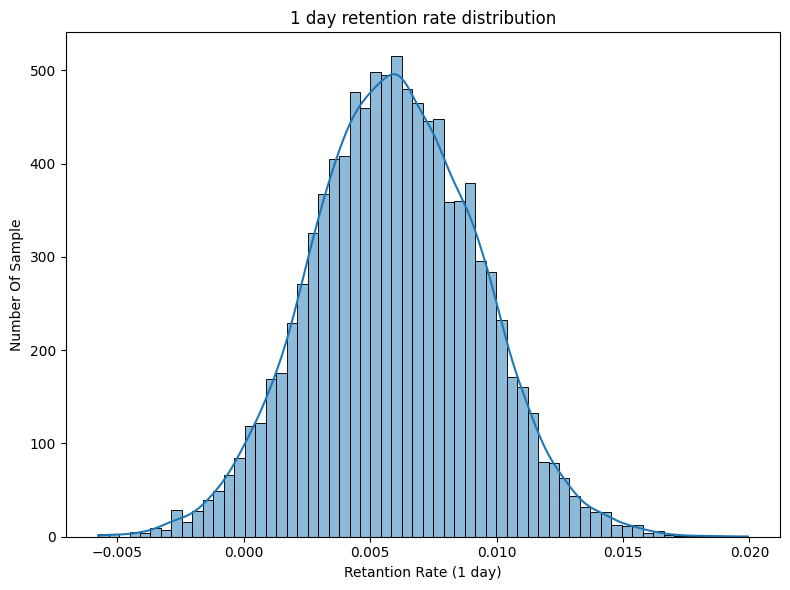

In [24]:
plt.figure(figsize=(8,6))
sns.histplot(data=boot_1d.bootstrap_distribution,kde=True)
plt.title("1 day retention rate distribution")
plt.xlabel('Retantion Rate (1 day)')
plt.ylabel('Number Of Sample')
plt.tight_layout()
plt.show()

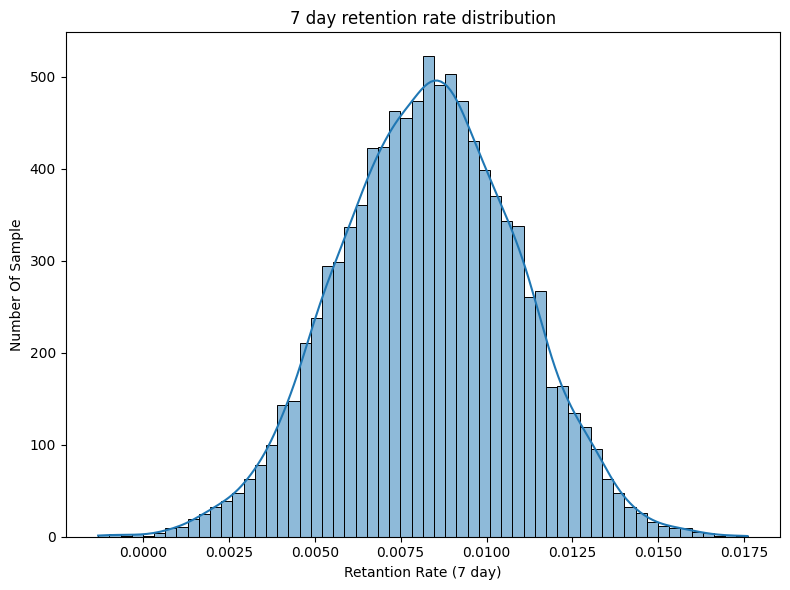

In [25]:
plt.figure(figsize=(8,6))
sns.histplot(data=boot_7d.bootstrap_distribution,kde=True)
plt.title("7 day retention rate distribution")
plt.xlabel('Retantion Rate (7 day)')
plt.ylabel('Number Of Sample')
plt.tight_layout()
plt.show()